<a href="https://colab.research.google.com/github/MDankloff/Delayed-Fairness-Project/blob/main/BAF_TryOut_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BAF calibrated version of cloned_ltf_pop.

same pipeline: generator/ simulator/ fair_model / baseline / utils / evaluation (LR, LCF, EO, DP)

same run and evaluate () workflow only the data source is BAF and the Banks ground truth bias change.

Sensitive attribute: income (split at 0.6 income), not age.
generator (k_same/k_other) thus works same.

In [76]:
#[Cell] Clone / mount, same as cloned_ltf_pop
import os
import sys

repo_url = "https://github.com/MDankloff/Delayed-Fairness-Project.git"
repo_dir = "/content/Delayed-Fairness-Project"

if not os.path.exists(repo_dir):
    os.system(f"git clone {repo_url} {repo_dir}")
else:
    os.system(f"git -C {repo_dir} pull origin main")

src_path = os.path.join(repo_dir, "Synthetic", "src")   # capital S
assert os.path.exists(os.path.join(src_path, "generator.py")), \
    f"generator.py not found at {src_path} -- check the clone succeeded"

if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Using:", src_path)


Using: /content/Delayed-Fairness-Project/Synthetic/src


# Libraries

In [77]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import yaml
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import glob
import joblib

import generator as gen_mod #gen_multi_steps_profiles lives only here
from generator import Agent as GenAgentBase        # used for the training-data bootstrap
from simulator import Bank, Agent as SimAgentBase, run_simulation
from evaluation import compute_statistics
from fair_model import FairModel
from baselines import LR, CvxFairModel, EOFairModel
from utils import combine_tuples

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

#!pip install mesa pandas scikit-learn networkx
#!pip install mesa==1.2.1
#from mesa import Model, Agent
#from mesa.time import RandomActivation
#from collections import defaultdict

# Load BAF data

Saved parquet files from csv

In [78]:
from google.colab import drive
drive.mount('/content/drive')
!cd '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
base_path = '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF/parquet data'

extension = "parquet" #parquet for smaller files, csv available
data_paths = glob.glob(f"{base_path}/*.{extension}")

def read_dataset(path, ext = extension):
    if ext == "csv":
      return pd.read_csv(path)
    elif ext == "parquet":
      return pd.read_parquet(path)
    else:
      raise ValueError(f"Unsupported file extension: {ext}")

# Extract variant name from the file path (without the extension)
def get_variant(path):
    return os.path.basename(path).split(".")[0]

# Dictionary comprehension to read all CSV files into a dictionary of DataFrames
dataframes = {
    get_variant(path): read_dataset(path) for path in data_paths
}
print(f"Loaded datasets: {list(dataframes.keys())}")

datasets_paths = {
    "Base": base_path + "/Base.parquet", # sampled to best represent original dataset
    "Variant I": base_path + "/Variant I.parquet", # higher group size disparity than base - reducing the size of the minority group from approx 20 - 10% of the dataset
    "Variant II": base_path + "/Variant II.parquet", # higher prevalence disparity than base - one group has 5 x the fraud detection rate of the other while group sizes are equal
    "Variant III": base_path + "/Variant III.parquet", # better separability for one of the groups
    "Variant IV": base_path + "/Variant IV.parquet", # higher prevalence disparity in train
    "Variant V": base_path + "/Variant V.parquet", # better separability in train for one of the groups
}

Loaded datasets: ['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']


In [80]:
#Rename datasets
base = dataframes['Base']
variant1 = dataframes['Variant I']
variant2 = dataframes['Variant II']
variant3 = dataframes['Variant III']
variant4 = dataframes['Variant IV']
variant5 = dataframes['Variant V']

#for better display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

dfs = [base, variant1, variant2, variant3, variant4, variant5]

#df4 = variant4 #set to preferred variant
#new_df4 = df4.copy()

base_df = base.copy() #set to preferred variant, natural bias, no the sensitivy-test variant, used for calibration

# Explore Data

In [81]:
#print(f"base_df: {len(base_df):,} rows")

In [82]:
#make a simplified df containing only a few features
base_simple = base_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()


In [83]:
# Display descriptive statistics for the 'income' column
display(base_simple['income'].describe())

,income
count,1000000.000000
mean,0.562696
std,0.290343
min,0.100000
25%,0.300000
50%,0.600000
75%,0.800000
max,0.900000


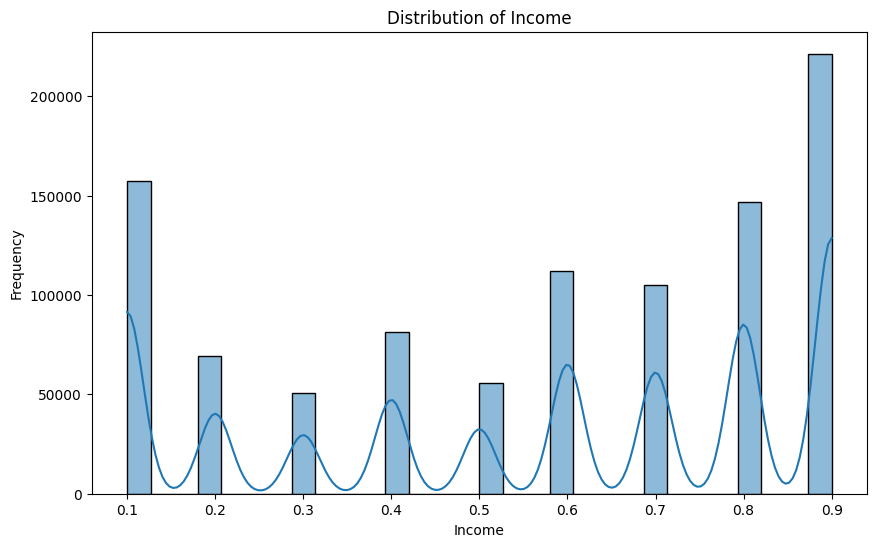

In [84]:
plt.figure(figsize=(10, 6))
sns.histplot(base_simple['income'], bins=30, kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

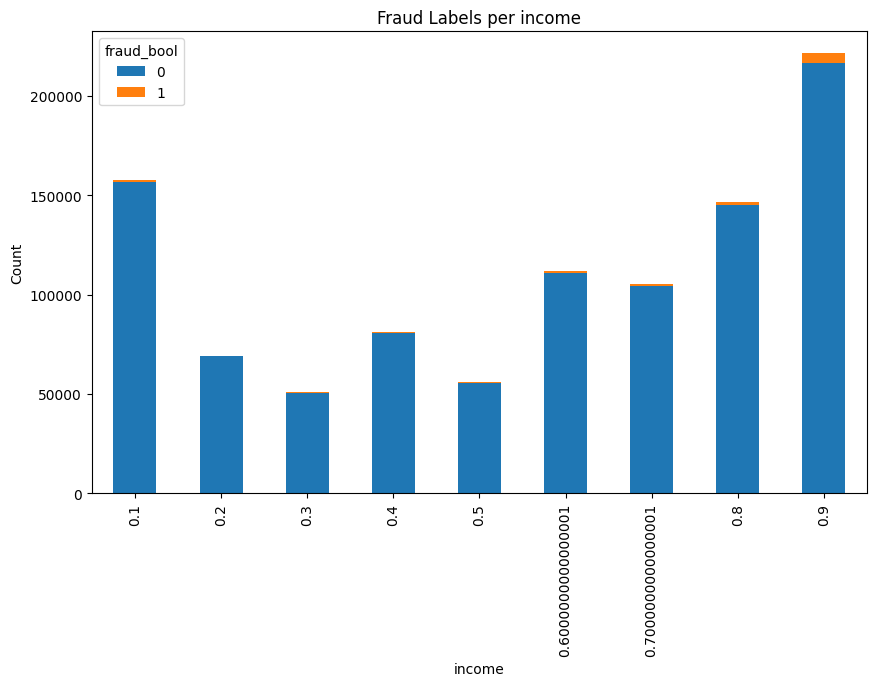

In [85]:
#fraud per income
fraud_per_month = base_simple.groupby(['income','fraud_bool']).size().unstack()
fraud_per_month.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Fraud Labels per income')
plt.xlabel('income')
plt.ylabel('Count')
plt.show()

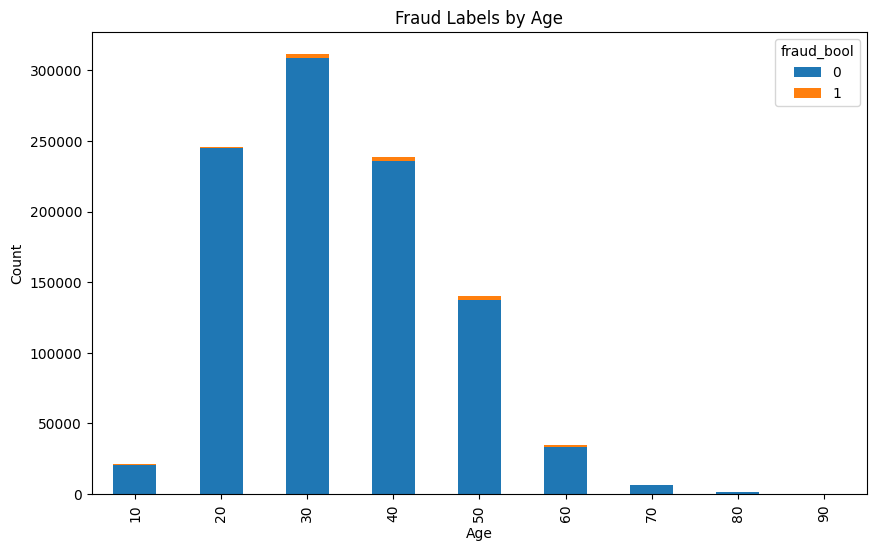

In [86]:
#fraud per age
fraud_per_age = base_simple.groupby(['customer_age','fraud_bool']).size().unstack()
fraud_per_age.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Fraud Labels by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [87]:
print(base_simple.iloc[0])

fraud_bool                  0.0
customer_age               40.0
income                      0.3
credit_risk_score         163.0
proposed_credit_limit    1500.0
Name: 0, dtype: float64


In [88]:
print(base_simple['income'].value_counts())
print(base_simple.groupby('income')['fraud_bool'].mean())

income
0.9    221419
0.1    157449
0.8    146650
0.6    111973
0.7    105109
0.4     81364
0.2     69345
0.5     55858
0.3     50833
Name: count, dtype: int64
income
0.1    0.005773
0.2    0.006316
0.3    0.006649
0.4    0.007337
0.5    0.007949
0.6    0.008779
0.7    0.008819
0.8    0.010924
0.9    0.021638
Name: fraud_bool, dtype: float64


In [89]:
base_simple.groupby('customer_age')['income'].mean()   # mean income by age group
# or
pd.crosstab(base_simple['customer_age'], base_simple['income'])

income,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
customer_age,,,,,,,,,
10,6359,2147,1379,1961,1171,2092,1722,1995,2161
20,51642,20781,14617,22527,14718,28382,24663,31377,37148
30,46607,21303,15954,25519,17673,35632,33592,46726,68427
40,28198,13751,10407,17294,12402,25884,26043,38445,66288
50,18051,8454,6381,10662,7464,15246,14660,21741,37694
60,5327,2342,1711,2780,1994,3829,3613,5185,7989
70,1040,470,308,513,355,775,674,966,1416
80,214,92,72,101,74,125,135,203,281
90,11,5,4,7,7,8,7,12,15


# Create demographic groups

Make exact 50/50 income split to get even split populations (not same as group split for graph).

income is decile-bucketed [0.1...0.9] in steps of 0.1, a huge nr of rows are at same median value.
A > or >= threshold throws that whole tied block to one side and breaks the balance. confirmed on the real data: `income > 0.600` gives 585,151 High / 414,849 Low (58.5% / 41.5%), not 50/50.

Fix: strictly-above -> High(1), strictly-below -> Low(0), and only the
tied-at-median block gets randomly split to make up the exact difference
(seeded, so reproducible). Confirmed on real Base data this gives an
exact 500,000 / 500,000 split with fraud rates 0.694% (Low) vs 1.512%
(High) -- a ~2.18x ratio, which is what Bank.params gets calibrated against below

In [90]:
def make_balanced_group(df, col, seed=42):
    """Return a 0/1 numpy array: exact 50/50 split of df[col], ties at the
    median broken randomly (reproducibly) rather than all going one way."""
    median_val = df[col].median()
    above = df[col] > median_val
    below = df[col] < median_val
    tied = df[col] == median_val

    n_total = len(df)
    target_high = n_total // 2
    n_needed_from_tied = max(0, target_high - above.sum())

    rng = np.random.default_rng(seed)
    tied_idx = df.index[tied].to_numpy()
    rng.shuffle(tied_idx)
    high_tied_idx = set(tied_idx[:n_needed_from_tied])

    group = np.where(
        above, 1,
        np.where(below, 0,
                 np.where(df.index.isin(high_tied_idx), 1, 0))
    ).astype(int)
    return group, median_val


In [91]:
base_simple['S'], median_income = make_balanced_group(base_simple, 'income', seed=42)
print(f"Median income: {median_income}")
print(base_simple['S'].value_counts())   # should be exactly 500,000 / 500,000

rate_low = base_simple.loc[base_simple.S == 0, 'fraud_bool'].mean()
rate_high = base_simple.loc[base_simple.S == 1, 'fraud_bool'].mean()
print(f"Fraud rate  S=0 (lower income): {rate_low*100:.3f}%")
print(f"Fraud rate  S=1 (higher income): {rate_high*100:.3f}%")
print(f"Rate ratio: {max(rate_low,rate_high)/min(rate_low,rate_high):.3f}x")



Median income: 0.6000000000000001
S
0    500000
1    500000
Name: count, dtype: int64
Fraud rate  S=0 (lower income): 0.694%
Fraud rate  S=1 (higher income): 1.512%
Rate ratio: 2.179x


In [92]:
base_simple['age_group'] = np.where(base_simple['customer_age'] >= 50, 'Older', 'Younger')
print(pd.crosstab(base_simple['age_group'], base_simple['S']))


S               0       1
age_group                
Older       83697   99316
Younger    416303  400684


fraud-rate gap by income: the nr Bank.params gets - calibrated against below.

<Axes: xlabel='income'>

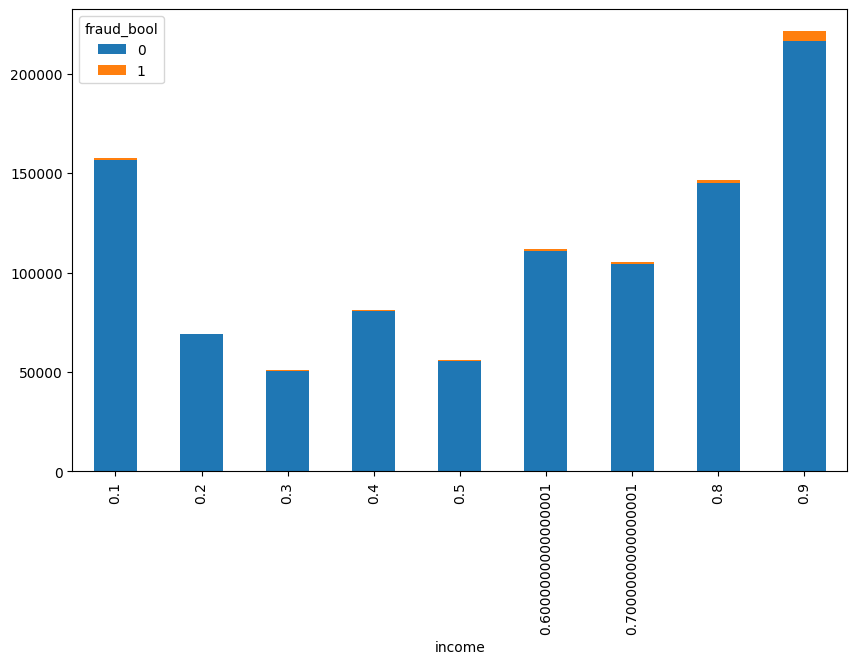

In [93]:
fraud_income_low=base_simple.groupby(['income','fraud_bool']).size().unstack()
fraud_income_low.plot(kind='bar', stacked=True, figsize=(10, 6))

# Make Feature Matrix for each applicant

Make feature matrix X: Each applicant i has a binary protected attribute S ∈ {0, 1} (e.g., age), a vector of dynamic features Xt ∈ Rd (e.g., credit risk score at time t), and a ground-truth label Yi,t ∈ {−1, 1} indicating whether the applicant can pay back (Yi,t =1) or default (Yi,t = −1).

In [94]:
#  Build feature matrix X a sensitive feature, 2 dynamic feature and the fraud bool (S, X_t = credit risk score, Y).
# Bank.params needs 4 values [w_s, w_x1, w_x2, w_intercept]

X_COLS = ['credit_risk_score', 'proposed_credit_limit']
X_all = base_simple[X_COLS].to_numpy(dtype=float)
X_all = (X_all - X_all.mean(axis=0)) / X_all.std(axis=0)   # z-score
s_all = base_simple['S'].to_numpy(dtype=int)
y_all = base_simple['fraud_bool'].to_numpy(dtype=int)

assert X_all.shape[1] == 2, "X_t should have exactly 2 features, matching the codebase's built-in assumption"



In [95]:
# Calibrate the ground-truth BANK from BAF data (replaces Bank.params = [2.5, 2, -1, -4.0]))
# fraud_bool: 1=fraud (bad). The simulation needs P(Y=1)=P(repay)=P(NOT fraud).
clf = LogisticRegression(max_iter=1000).fit(np.c_[s_all, X_all], 1 - y_all)   # <-- flip target
w_s, w_x1, w_x2 = clf.coef_[0]
w_0 = clf.intercept_[0]
print(f"Calibrated Bank.params = [{w_s:.3f}, {w_x1:.3f}, {w_x2:.3f}, {w_0:.3f}]")
print(f"(partial, feature-controlled income effect: exp({w_s:.3f}) = {np.exp(w_s):.3f}x odds)")

bank = Bank(params=np.array([w_s, w_x1, w_x2, w_0]))



# important!: generator.py's agent.gen_next_profile hardcodes a bank() inside itself (generator.bank) and is different from simulator.bank.
# to compute the ground-truth repayment/default outcome during the training bootstrap it ignores whatever `bank`/`model` object passes
# Original hidden Bank() still has the original synthetic 4-value default (`params = np.array([2.5, 2, -1, -4.0])`),
# Patch class attribute here so that hidden call also uses the calibrated, 3-parameter income-conditioned bias:

gen_mod.Bank.params = np.array([w_s, w_x1, w_x2, w_0])   # fixes generator.py's internal Bank()
Bank.params = np.array([w_s, w_x1, w_x2, w_0])           # fixes simulator.py's internal Bank() (Bank == simulator.Bank here)



Calibrated Bank.params = [-0.634, -0.409, -0.252, 5.089]
(partial, feature-controlled income effect: exp(-0.634) = 0.530x odds)


# BAF agent class
Draw applicants from BAF data instead of synthetic gaussian clusters

gen_init_profile() creates the starting population (s, x, at t=0). In the original code this is drawn from two gaussian clusters, now we draw it from base_df.

Two thin subclasses because generator.Agent and simulator.Agent are used in two different places below (training bootstrap vs. the actual networked simulation) and are NOT interchangeable.


In [96]:
class _BAFInitMixin:
    def __init__(self, s_pool, X_pool, n_samples, protect_ratio=0.5, eps=0.5,
                 base=(0.2, 1.0), seed=2021):
        super().__init__(n_samples=n_samples, protect_ratio=protect_ratio,
                          eps=eps, base=base, seed=seed)
        self._s_pool = s_pool
        self._X_pool = X_pool

    def gen_init_profile(self):
        rng = np.random.default_rng(self.seed)
        n0 = np.where(self._s_pool == 0)[0]
        n1 = np.where(self._s_pool == 1)[0]
        # sample exactly n_samples/2 from each group so the population fed
        # into the graph generator is EXACTLY balanced (the full pool is
        # 50/50 thanks to make_balanced_group, but a plain random draw of
        # n_samples rows from it won't be exactly balanced on its own)
        half = self.n_samples // 2
        idx0 = rng.choice(n0, size=half, replace=False)
        idx1 = rng.choice(n1, size=self.n_samples - half, replace=False)
        idx = np.concatenate([idx0, idx1])
        rng.shuffle(idx)
        s = self._s_pool[idx].astype(float)
        X = self._X_pool[idx].copy()
        return s, X




In [97]:
class BAFAgentGen(_BAFInitMixin, GenAgentBase):
    """For generator.gen_multi_step_profiles() the training-data bootstrap."""
    pass


In [98]:
class BAFAgentSim(_BAFInitMixin, SimAgentBase):
    """For simulator.run_simulation() the actual networked simulation."""
    pass


In [99]:
agent_train = BAFAgentGen(s_all, X_all, n_samples=4000, eps=0.5, base=[0.2, 1.0], seed=2026)
agent_test  = BAFAgentSim(s_all, X_all, n_samples=1000, eps=0.5, base=[0.2, 1.0], seed=2027)


In [100]:
# sanity check: population fed to the graph generator really is 50/50
#s_check, _ = agent_test.gen_init_profile()
#print("agent_test group balance:", np.bincount(s_check.astype(int)))



# Generate training data and train four models
identical to cloned_ltf_pop

In [101]:
s_train, Xs_train, Ys_train = gen_mod.gen_multi_step_profiles(bank, agent_train, steps=5)
s_comb, X_comb, Y_comb = combine_tuples(s_train, Xs_train, Ys_train)
d = X_comb.shape[1]

# Baseline (LR)
lr = LR(l2_reg=1e-5)
lr.train(s_comb, X_comb, Y_comb)

# Hu's LCF
LCF = FairModel(n_features=d + 1, lr=5e-3, l2_reg=1e-5, sf_reg=0.119, lf_reg=0.154)
LCF.train(s_train, Xs_train, Ys_train, Xs_train, Ys_train, epochs=1000, plot=False)

num_iters = 50
for t in range(num_iters):
    _, NXs_train, NYs_train = gen_mod.gen_multi_step_profiles(LCF, agent_train, steps=5)
    LCF.train(s_train, Xs_train, Ys_train, NXs_train, NYs_train, epochs=10, plot=False)
print("LCF Retraining Done!")

# DP model
dp_model = CvxFairModel(n_features=d + 1, l2_reg=1e-5, tao=1.565)
dp_model.train(s_comb, X_comb, Y_comb)

# EO model
eo_model = EOFairModel(n_features=d + 2, l2_reg=1e-5, tao=1.5)
eo_model.train(s_comb, X_comb, Y_comb)





LCF Retraining Done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6540
[Fair Model with Equal Oppertunity] status: optimal_inaccurate, loss: 0.6532


/usr/local/lib/python3.12/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


# Run and evaluate

In [102]:
#identical run_and_evaluate() from cloned_ltf_pop
def run_and_evaluate(model, model_name, bank, agent, steps=5):
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=2026,
        seed=2026,
        decision_coef=0.8,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys)

    print(f"\nRetention rates ({model_name}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


In [103]:
print("\n" + "=" * 60 + "\nRUNNING ALL SIMULATIONS (BAF-calibrated, income as S)\n" + "=" * 60)
results_lr  = run_and_evaluate(lr,        "Baseline (LR)",  bank, agent_test)
results_lcf = run_and_evaluate(LCF,       "LCF (Hu et al.)", bank, agent_test)
results_eo  = run_and_evaluate(eo_model,  "EO",              bank, agent_test)
results_dp  = run_and_evaluate(dp_model,  "DP",              bank, agent_test)



RUNNING ALL SIMULATIONS (BAF-calibrated, income as S)

=== Baseline (LR) ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 66.8%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 67.3%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 66.5%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.063
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 63.5%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.077
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 64.0%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.249



Retention rates (Baseline (LR)):
Step 1: Retention=100.0%, R(S=0)=100.0%, R(S=1)=100.0%, Disparity=0.0%


# Extract metrics for plots

In [104]:
import evaluation
from evaluation import compute_post_long_cond_fairness, compute_post_long_cond_probs

In [105]:
# Patch compute_post_long_cond_probs to clip probabilities before dividing which prevents the ratio from exploding when BAF's rare fraud rate
# (~1%) pushes a denominator probability close to 0. Same idea as "propensity score trimming" in the causal inference literature.

def _safe_compute_post_long_cond_probs(s, Xs, Ys, clip=0.05):
    probs = {}
    for i in range(len(Xs) - 1):
        for group_val, label in [(1, 'pos'), (0, 'neg')]:
            mask = s == group_val
            XXs_comb = np.c_[s[mask], Xs[i][mask], Xs[i + 1][mask]]
            Xs_comb = np.c_[s[mask], Xs[i][mask]]
            lr_up = LogisticRegression(max_iter=1000, random_state=2021).fit(XXs_comb, Ys[i][mask])
            lr_dn = LogisticRegression(max_iter=1000, random_state=2021).fit(Xs_comb, Ys[i][mask])
            probs_up = lr_up.predict_proba(XXs_comb)
            probs_dn = np.clip(lr_dn.predict_proba(Xs_comb), clip, 1 - clip)   # <-- the fix
            probs[f'{label}(y{i+1}=0)'] = probs_up[:, 0] / probs_dn[:, 0]
            probs[f'{label}(y{i+1}=1)'] = probs_up[:, 1] / probs_dn[:, 1]
    return probs

evaluation.compute_post_long_cond_probs = _safe_compute_post_long_cond_probs
compute_post_long_cond_probs = _safe_compute_post_long_cond_probs   # so e

def extract_metrics(result_tuple, model):
    s, Xs, Ys, Ds, As = result_tuple
    s_arr = np.array(s)
    ret_s0, ret_s1, disparity, unfairness = [], [], [], []

    for i in range(len(As)):
        A_t = np.array(As[i])
        r0 = A_t[s_arr == 0].mean() * 100
        r1 = A_t[s_arr == 1].mean() * 100
        ret_s0.append(r0)
        ret_s1.append(r1)
        disparity.append(abs(r0 - r1))

        # same computation compute_statistics() uses for "Long fairness"
        if i == 0:
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model)
        else:
            probs = compute_post_long_cond_probs(s, Xs[:i+1], Ys[:i+1])
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model, probs)
        unfairness.append(abs(plcf))

    return {'S=0': ret_s0, 'S=1': ret_s1, 'disparity': disparity, 'unfairness': unfairness}


results = {
    'Baseline': extract_metrics(results_lr, lr),
    'LCF': extract_metrics(results_lcf, LCF),
    'EO': extract_metrics(results_eo, eo_model),
    'DP': extract_metrics(results_dp, dp_model),
}

steps = list(range(1, len(results['Baseline']['S=0']) + 1))

# Create Figures

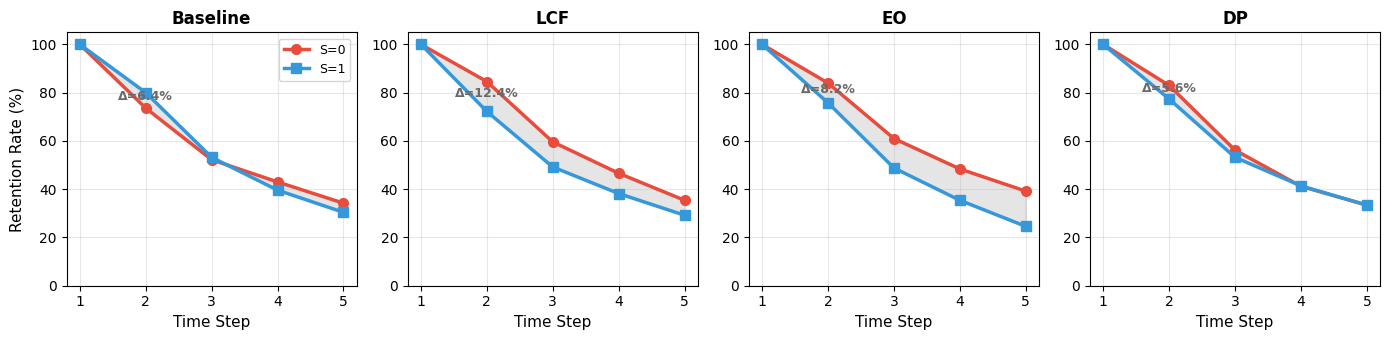

In [106]:
#Figure 1 Retention rates by group (4-panel)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}

methods = list(results.keys())
for idx, method in enumerate(methods):
    ax = axes[idx]
    ax.plot(steps, results[method]['S=0'], 'o-', color=colors['S=0'], label='S=0', linewidth=2.5, markersize=7)
    ax.plot(steps, results[method]['S=1'], 's-', color=colors['S=1'], label='S=1', linewidth=2.5, markersize=7)
    ax.fill_between(steps, results[method]['S=0'], results[method]['S=1'], alpha=0.2, color='gray')

    disparity_t2 = results[method]['disparity'][1]
    mid_y = (results[method]['S=0'][1] + results[method]['S=1'][1]) / 2
    ax.annotate(f'Δ={disparity_t2:.1f}%', xy=(2, mid_y), fontsize=9, ha='center', color='dimgray', fontweight='bold')

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_xticks(steps)
    ax.set_xlabel('Time Step', fontsize=11)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.set_ylabel('Retention Rate (%)', fontsize=11)
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

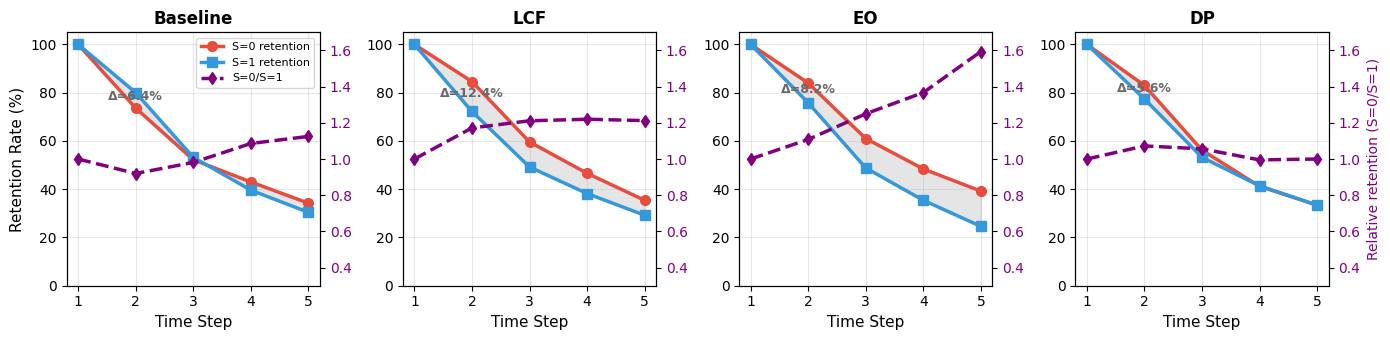

In [107]:
# Figure 2 Retention by group + relative retention ratio (twin axis, 4-panel)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
left_colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}
ratio_color = 'purple'

for idx, method in enumerate(methods):
    ax = axes[idx]
    ax2 = ax.twinx()

    s0 = np.array(results[method]['S=0'], dtype=float)
    s1 = np.array(results[method]['S=1'], dtype=float)
    ratio = np.divide(s0, s1, out=np.full_like(s0, np.nan), where=(s1 != 0))

    l1, = ax.plot(steps, s0, 'o-', color=left_colors['S=0'], label='S=0 retention', linewidth=2.5, markersize=7)
    l2, = ax.plot(steps, s1, 's-', color=left_colors['S=1'], label='S=1 retention', linewidth=2.5, markersize=7)
    ax.fill_between(steps, s0, s1, alpha=0.2, color='gray')
    l3, = ax2.plot(steps, ratio, 'd--', color=ratio_color, label='S=0/S=1', linewidth=2.5, markersize=6)

    disparity_t2 = results[method]['disparity'][1]
    mid_y = (s0[1] + s1[1]) / 2
    ax.annotate(f'Δ={disparity_t2:.1f}%', xy=(2, mid_y), fontsize=9, ha='center', color='dimgray', fontweight='bold')

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_xticks(steps)
    ax.set_xlabel('Time Step', fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == len(methods) - 1:
        ax2.set_ylabel('Relative retention (S=0/S=1)', fontsize=10, color=ratio_color)
    ax2.tick_params(axis='y', labelcolor=ratio_color)
    ax2.set_ylim(0.3, 1.7)

    if idx == 0:
        ax.set_ylabel('Retention Rate (%)', fontsize=11)
        ax.legend(handles=[l1, l2, l3], loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

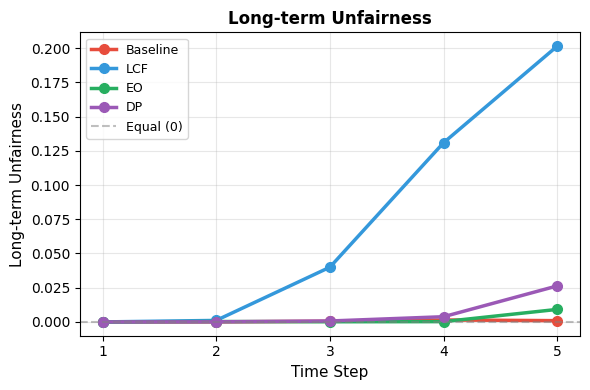

In [108]:
# Figure 3 Merged long-term unfairness (single plot)
method_colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6'}

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for method in methods:
    ax.plot(steps, results[method]['unfairness'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)

ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Long-term Unfairness', fontsize=11)
ax.set_title('Long-term Unfairness', fontsize=12, fontweight='bold')
ax.set_xticks(steps)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('long_term_unfairness_merged.png', dpi=300, bbox_inches='tight')
plt.savefig('long_term_unfairness_merged.pdf', bbox_inches='tight')
plt.show()


In [109]:
# Detailed metrics table reuses results_lr/lcf/eo/dp directly,
# NO second run_simulation() call needed (the original notebook's run_and_store() duplicated work that results_lr/lcf/eo/dp already contain).
def compute_detailed_metrics(s, As, Ds, Ys):
    s = np.array(s)
    n_s0_total = np.sum(s == 0)
    n_s1_total = np.sum(s == 1)

    print("Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)")
    print("-" * 120)

    metrics = {'s0_share': [], 'rep_ratio': [], 'signed_delta': [], 'retention_s0': [], 'retention_s1': [],
               'disparity': [], 'h_s0': [], 'h_s1': [], 'h_ratio': []}

    prev_active_s0 = prev_active_s1 = None

    for t in range(len(As)):
        A_t = np.array(As[t])
        D_t = np.array(Ds[t])

        active_s0 = np.sum((s == 0) & (A_t == 1))
        active_s1 = np.sum((s == 1) & (A_t == 1))
        total_active = active_s0 + active_s1
        s0_share = active_s0 / total_active if total_active > 0 else 0

        retention_s0 = (active_s0 / n_s0_total) * 100 if n_s0_total > 0 else np.nan
        retention_s1 = (active_s1 / n_s1_total) * 100 if n_s1_total > 0 else np.nan
        disparity = abs(retention_s0 - retention_s1)
        rep_ratio = retention_s0 / retention_s1 if retention_s1 and retention_s1 > 0 else np.nan

        if t == 0:
            h_s0 = h_s1 = 1.0
        else:
            h_s0 = (active_s0 / prev_active_s0) if (prev_active_s0 is not None and prev_active_s0 > 0) else np.nan
            h_s1 = (active_s1 / prev_active_s1) if (prev_active_s1 is not None and prev_active_s1 > 0) else np.nan
        h_ratio = (h_s0 / h_s1) if (h_s1 is not None and not np.isnan(h_s1) and h_s1 != 0) else np.nan

        prev_active_s0, prev_active_s1 = active_s0, active_s1

        active_mask = A_t == 1
        if active_s0 > 0 and active_s1 > 0:
            approval_s0 = np.mean(D_t[(s == 0) & active_mask])
            approval_s1 = np.mean(D_t[(s == 1) & active_mask])
            signed_delta = approval_s0 - approval_s1
        else:
            signed_delta = np.nan

        for k, v in zip(['s0_share','rep_ratio','signed_delta','retention_s0','retention_s1','disparity','h_s0','h_s1','h_ratio'],
                         [s0_share, rep_ratio, signed_delta, retention_s0, retention_s1, disparity, h_s0, h_s1, h_ratio]):
            metrics[k].append(v)

        print(f"  {t+1}  |  {active_s0:4d}  |  {active_s1:4d}  |   {s0_share:.2f}    |    {rep_ratio:6.2f}  |"
              f"  {h_s0:5.2f}  |  {h_s1:5.2f}  |  {h_ratio:6.2f}  |      {signed_delta:+.3f}")

    return metrics


print("\n=== Baseline ===")
metrics_baseline = compute_detailed_metrics(results_lr[0], results_lr[4], results_lr[3], results_lr[2])
print("\n=== LCF ===")
metrics_LCF = compute_detailed_metrics(results_lcf[0], results_lcf[4], results_lcf[3], results_lcf[2])
print("\n=== EO ===")
metrics_eo = compute_detailed_metrics(results_eo[0], results_eo[4], results_eo[3], results_eo[2])
print("\n=== DP ===")
metrics_dp = compute_detailed_metrics(results_dp[0], results_dp[4], results_dp[3], results_dp[2])

all_metrics = {'Baseline': metrics_baseline, 'LCF': metrics_LCF, 'EO': metrics_eo, 'DP': metrics_dp}


=== Baseline ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |   1.00  |    1.00  |      -0.038
  2  |   368  |   400  |   0.48    |      0.92  |   0.74  |   0.80  |    0.92  |      +0.014
  3  |   261  |   266  |   0.50    |      0.98  |   0.71  |   0.67  |    1.07  |      +0.082
  4  |   215  |   198  |   0.52    |      1.09  |   0.82  |   0.74  |    1.11  |      +0.064
  5  |   171  |   152  |   0.53    |      1.13  |   0.80  |   0.77  |    1.04  |      +0.090

=== LCF ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |   1.00  

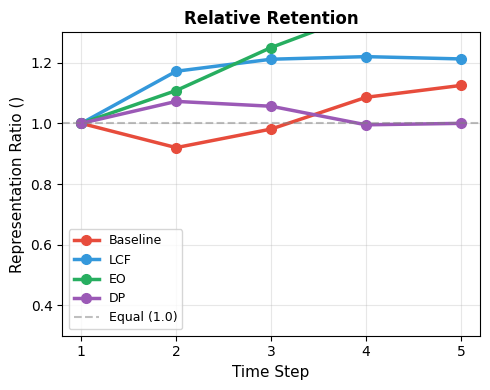

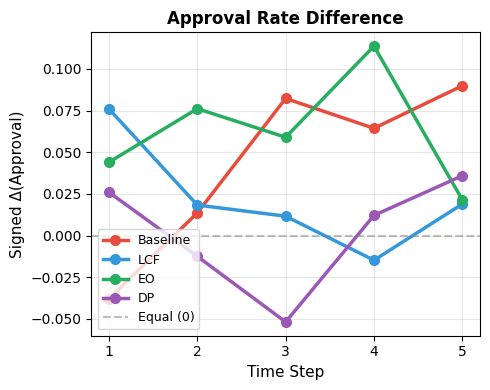

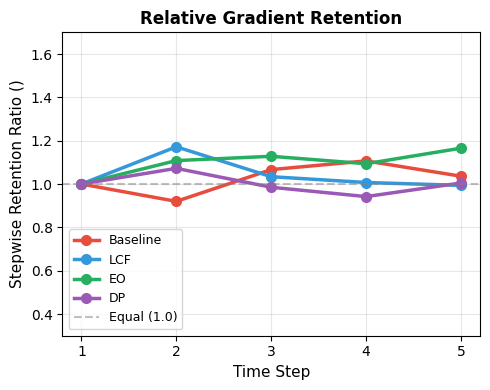

In [110]:
# Figures 4-6 -- H-linecharts (rep_ratio, signed_delta, h_ratio)
single_figsize = (5, 4)

fig, ax = plt.subplots(1, 1, figsize=single_figsize)
for method in methods:
    ax.plot(steps, all_metrics[method]['rep_ratio'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Representation Ratio ()', fontsize=11)
ax.set_title('Relative Retention', fontsize=12, fontweight='bold')
ax.set_ylim(0.3, 1.3); ax.set_xticks(steps); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('relative_retention.png', dpi=300, bbox_inches='tight'); plt.savefig('relative_retention.pdf', bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(1, 1, figsize=single_figsize)
for method in methods:
    ax.plot(steps, all_metrics[method]['signed_delta'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Signed Δ(Approval)', fontsize=11)
ax.set_title('Approval Rate Difference', fontsize=12, fontweight='bold')
ax.set_xticks(steps); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('approval_rate_difference.png', dpi=300, bbox_inches='tight'); plt.savefig('approval_rate_difference.pdf', bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(1, 1, figsize=single_figsize)
for method in methods:
    ax.plot(steps, all_metrics[method]['h_ratio'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Stepwise Retention Ratio ()', fontsize=11)
ax.set_title('Relative Gradient Retention', fontsize=12, fontweight='bold')
ax.set_xticks(steps); ax.set_ylim(0.3, 1.7); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('relative_gradient_retention.png', dpi=300, bbox_inches='tight'); plt.savefig('relative_gradient_retention.pdf', bbox_inches='tight'); plt.show()

In [111]:
print(base_simple[['credit_risk_score', 'proposed_credit_limit']].corr())

                       credit_risk_score  proposed_credit_limit
credit_risk_score               1.000000               0.606141
proposed_credit_limit           0.606141               1.000000
